# 300. Longest Increasing Subsequence

Given an integer array nums, return the length of the longest strictly increasing

Example 1:

Input: nums = [10,9,2,5,3,7,101,18]
Output: 4
Explanation: The longest increasing subsequence is [2,3,7,101], therefore the length is 4.

## Example 2:

Input: nums = [0,1,0,3,2,3]
Output: 4

## Example 3:

Input: nums = [7,7,7,7,7,7,7]
Output: 1


Constraints:

    1 <= nums.length <= 2500
    -10^4 <= nums[i] <= 10^4

Optimizing tool selection...Claro! Segue o template de resolução para o problema "Longest Increasing Subsequence" (LIS) no estilo solicitado:

---

1️⃣ #Specification (Especificação de Engenharia)

**Core:**  
Dado um array de inteiros, encontre o comprimento da subsequência crescente mais longa (LIS), onde os elementos não precisam ser consecutivos, apenas em ordem crescente.  
O objetivo é maximizar o tamanho dessa subsequência, respeitando a ordem dos elementos originais.

**Blueprint (Python Type Hints):**
```python
from typing import List

class Solution:
    def lengthOfLIS(self, nums: List[int]) -> int:
        ...
```

**Edge Cases & Traps:**
- Array vazio (deve retornar 0).
- Todos os elementos iguais (LIS = 1).
- Array já ordenado (LIS = len(nums)).
- Array em ordem decrescente (LIS = 1).
- Arrays grandes (N > 10^4) — soluções O(N^2) podem TLE.

---

2️⃣ #Plan (A Heurística e o Desenho Técnico)

**A Ponte da Intuição (Brute Force):**  
Tentar todas as subsequências possíveis e checar se são crescentes — complexidade exponencial O(2^N), inviável para N > 20.

**O Gargalo:**  
A abordagem de tentar todas as combinações explode em tempo, pois o número de subsequências cresce exponencialmente.

**Heurística Otimizada:**  
Usar Programação Dinâmica (DP) — para cada posição, guardar o tamanho da maior subsequência crescente terminando ali.  
Para otimizar ainda mais, podemos usar uma abordagem com Binary Search (patience sorting), reduzindo para O(N log N).

**Visual Trace (High-Level Simulation):**

Exemplo: nums = [10, 9, 2, 5, 3, 7, 101, 18]

DP array (cada posição guarda o tamanho da LIS terminando ali):

| i | nums[i] | dp[i] | Explicação                      |
|---|---------|-------|---------------------------------|
| 0 |   10    |   1   | Só ele mesmo                    |
| 1 |    9    |   1   | 9 < 10, não cresce             |
| 2 |    2    |   1   | 2 < 9, não cresce              |
| 3 |    5    |   2   | 2 < 5, então dp[2]+1 = 2       |
| 4 |    3    |   2   | 2 < 3, então dp[2]+1 = 2       |
| 5 |    7    |   3   | 5 < 7, então dp[3]+1 = 3       |
| 6 |  101    |   4   | 7 < 101, então dp[5]+1 = 4     |
| 7 |   18    |   4   | 7 < 18, então dp[5]+1 = 4      |

Resposta: max(dp) = 4


**Comentários de Decisão:**  
- Usamos dois loops para comparar cada elemento com todos os anteriores, pois precisamos saber se podemos estender uma subsequência crescente.
- O array dp armazena o melhor resultado até cada posição, evitando recomputação.

---

4️⃣ #Complexity (Veredito Final)

- **Time Complexity:** O(N^2) — dois loops aninhados, cada um até N.
- **Space Complexity:** O(N) — array dp para armazenar o LIS até cada posição.

Se quiser a versão O(N log N) com binary search, posso complementar!

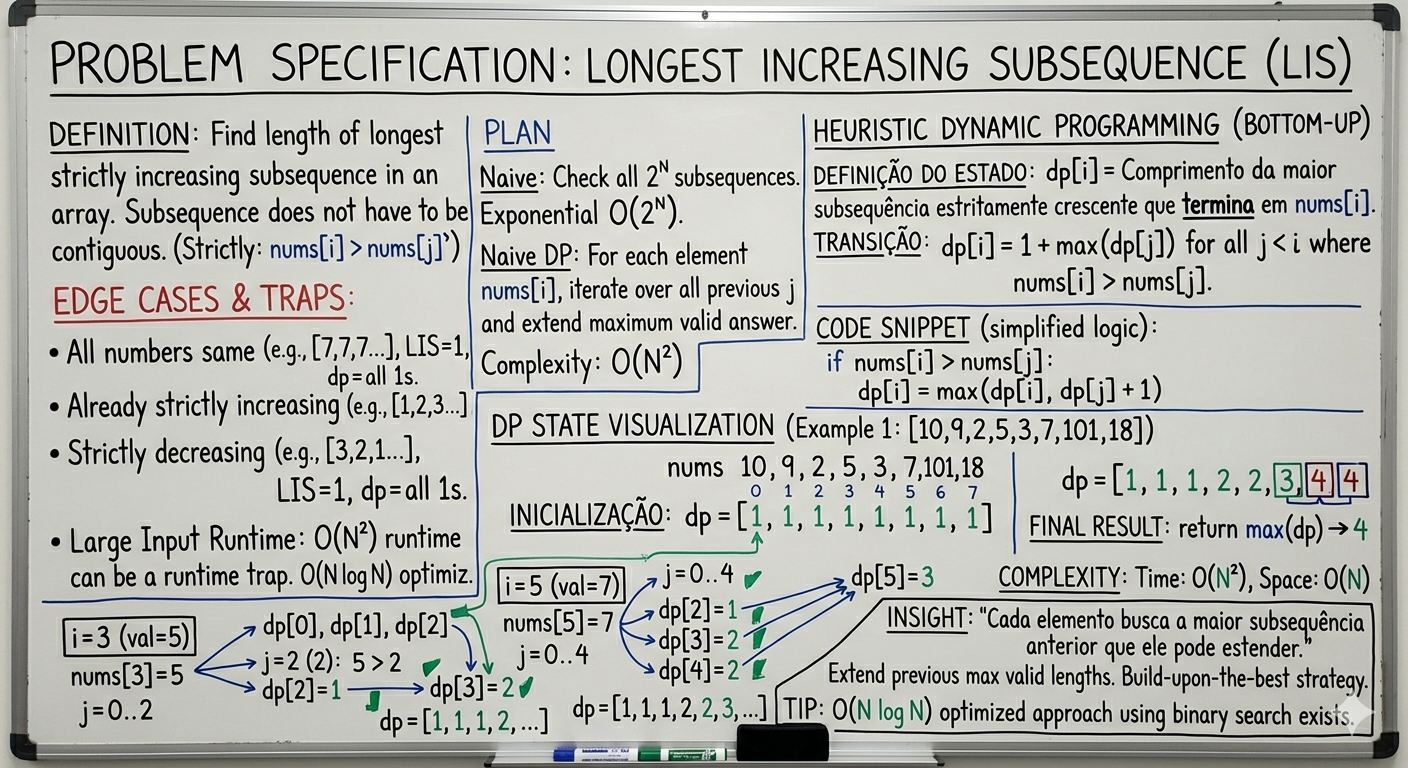

In [1]:
from typing import List

class Solution:
    def lengthOfLIS(self, nums: List[int]) -> int:
        n = len(nums)
        max_sequence = 1
        # dp[i] will store the length of the longest increasing subsequence ending at nums[i]
        dp = [1] * n  # Each element itself is a subsequence of length 1
        
        # Go through each element in the array
        for i in range(n):
            # Look at all previous elements before nums[i]
            for j in range(i):
                # If nums[i] can extend the subsequence ending at nums[j]
                if nums[i] > nums[j]:
                    # Update dp[i] by extending dp[j] subsequence
                    dp[i] = max(dp[i], dp[j] + 1)
                    max_sequence = max(max_sequence,dp[i])
                    # Now dp[i] is the length of the longest subsequence ending at i
        
        return max_sequence
    
Solution().lengthOfLIS([10,9,2,5,3,7,101,18])

4